In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import calendar

sns.set_theme(style="whitegrid")
sns.set_context("paper", font_scale=1.2)

In [2]:
df = pd.read_csv("./../final5.csv")
df.head()

,index,verbatimScientificName,stateProvince,individualCount,decimalLatitude,decimalLongitude,eventDate,avg_rad,cf_cvg,NDVI_raw,...,TOTEXTTAU,TOTSCATAU,temp_mean,temp_max,temp_min,rainfall,wind_mean,humid_mean,shortwave_radiation,lka_general_2020
0,0,Anarhynchus alexandrinus,Mannar,8.0,9.058512,79.855020,2021-01-06,0.66,5.0,3792.0,...,0.175115,0.165737,26.58,28.52,24.74,15.17,1.31,85.53,17.65,2.805795
1,1,Columba livia,Colombo,31.0,6.927894,79.865005,2024-09-24,25.40,1.0,5692.0,...,0.191869,0.184795,27.52,29.55,26.03,2.63,5.50,84.41,20.77,39.099075
2,2,Hirundo rustica,Colombo,10.0,6.866285,79.931440,2024-12-23,10.16,7.0,7045.0,...,0.198127,0.187366,26.21,28.84,24.10,0.25,2.51,84.30,20.49,8.917330
3,3,Geokichla spiloptera,Matale,1.0,7.401229,80.690730,2024-09-13,1.13,1.0,9506.0,...,0.162928,0.156176,27.29,32.96,23.45,0.17,4.11,76.89,22.42,11.386136
4,4,Himantopus himantopus,Puttalam,6.0,8.154166,79.736084,2024-11-28,0.79,2.0,NaN,...,0.213164,0.203239,25.86,27.55,24.85,0.99,6.15,84.07,8.78,3.522320


In [30]:
df['eventDate'] = pd.to_datetime(df['eventDate'])
df['Year'] = (df['eventDate'].dt.year).astype(int)
df['Month'] = (df['eventDate'].dt.month).astype(int)
df['Day'] = (df['eventDate'].dt.day).astype(int)

df[['eventDate', 'Month', 'Year', 'Day']].head()

,eventDate,Month,Year,Day
0,2021-01-06,1,2021,6
1,2024-09-24,9,2024,24
2,2024-12-23,12,2024,23
3,2024-09-13,9,2024,13
4,2024-11-28,11,2024,28


**How light pollution is growing over the years**

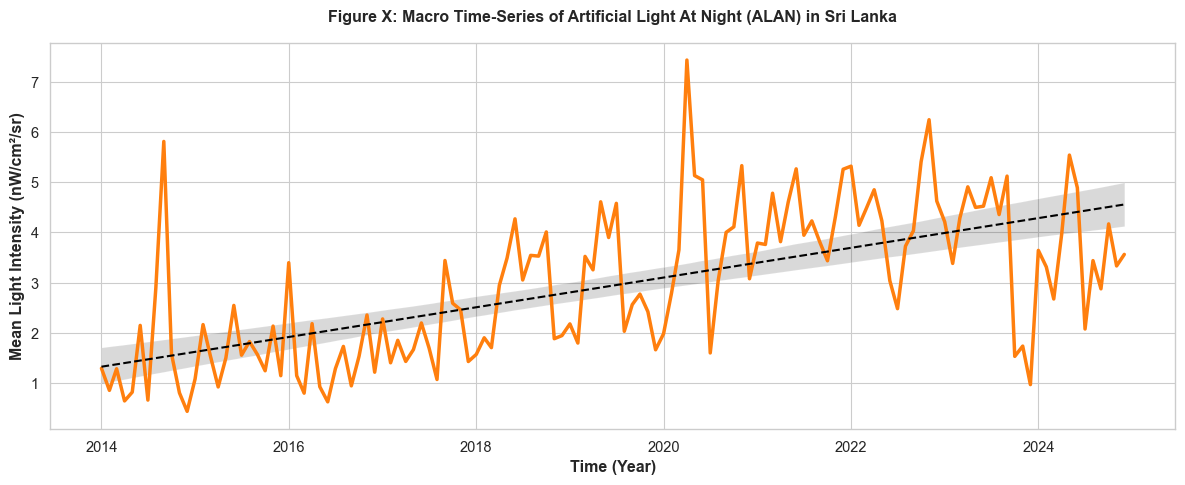

In [ ]:
alan_ts = df.groupby(['Year', 'Month'])['avg_rad'].mean().reset_index()
alan_ts['Date'] = pd.to_datetime(alan_ts[['Year', 'Month']].assign(DAY=1))
alan_ts['Date_num'] = mdates.date2num(alan_ts['Date'])

plt.figure(figsize=(12, 5))

sns.lineplot(x='Date', y='avg_rad', data=alan_ts, color='#ff7f0e', linewidth=2.5)

sns.regplot(x='Date_num', y='avg_rad', data=alan_ts, 
            scatter=False, color='black', line_kws={'linestyle':'--', 'linewidth': 1.5})

plt.title("Figure X: Macro Time-Series of Artificial Light At Night (ALAN) in Sri Lanka", fontweight='bold', pad=15)
plt.xlabel("Time (Year)", fontweight='bold')
plt.ylabel("Mean Light Intensity (nW/cm²/sr)", fontweight='bold')

plt.tight_layout()
plt.show()

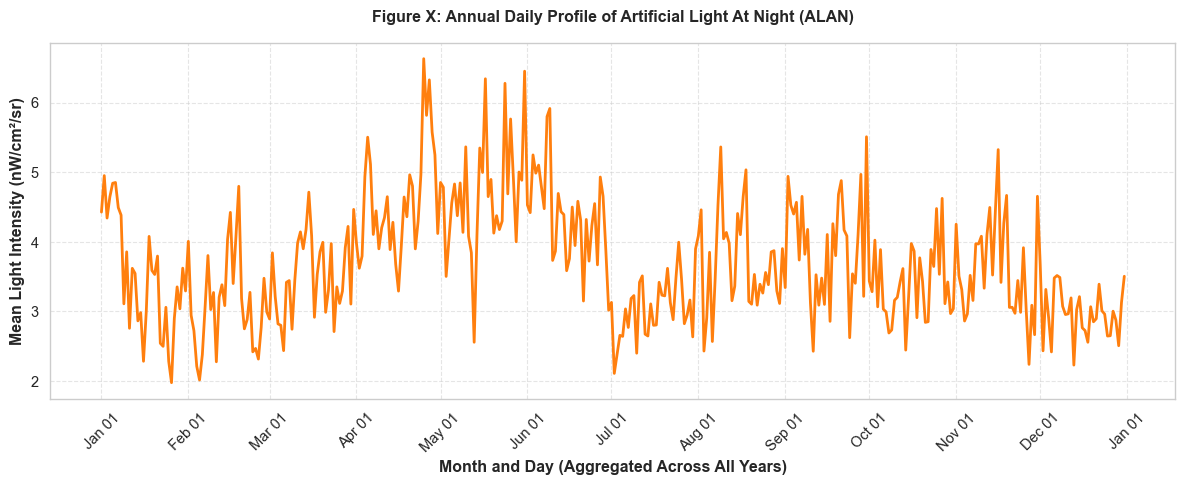

In [ ]:
alan_daily_profile = df.groupby(['Month', 'Day'])['avg_rad'].mean().reset_index()

alan_daily_profile['Generic_Date'] = pd.to_datetime(
    dict(year=2020, month=alan_daily_profile['Month'], day=alan_daily_profile['Day'])
)

plt.figure(figsize=(12, 5))
sns.lineplot(x='Generic_Date', y='avg_rad', data=alan_daily_profile, color='#ff7f0e', linewidth=2)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d')) 
ax.xaxis.set_major_locator(mdates.MonthLocator()) 

plt.title("Figure X: Annual Daily Profile of Artificial Light At Night (ALAN)", fontweight='bold', pad=15)
plt.xlabel("Month and Day (Aggregated Across All Years)", fontweight='bold')
plt.ylabel("Mean Light Intensity (nW/cm²/sr)", fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

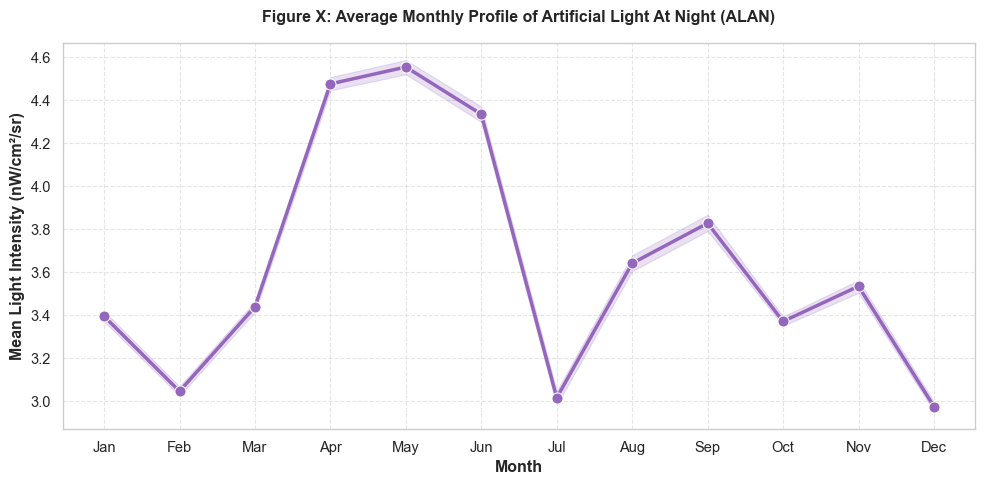

In [ ]:
df_sorted = df.sort_values('Month')
month_map = {i: calendar.month_abbr[i] for i in range(1, 13)}
df_sorted['Month_Name'] = df_sorted['Month'].map(month_map)

plt.figure(figsize=(10, 5))

sns.lineplot(
    x='Month_Name', 
    y='avg_rad', 
    data=df_sorted, 
    color='#9467bd', 
    linewidth=2.5, 
    marker='o', 
    markersize=8,
    sort=False
)

plt.title("Figure X: Average Monthly Profile of Artificial Light At Night (ALAN)", fontweight='bold', pad=15)
plt.xlabel("Month", fontweight='bold')
plt.ylabel("Mean Light Intensity (nW/cm²/sr)", fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()